# 12. Classification I: Logistic Regression
@Shengli (Bruce) Jiang, University of South Carolina

Can two chemical measurements identify a wine cultivar?

This notebook introduces binary and multiclass classification with logistic regression.

## What We Have Covered

- Python, NumPy, pandas, functions, and plotting
- Linear and nonlinear regression
- Training, validation, and test data
- RMSE, MAE, R-squared, regularization, and cross-validation
- Scaling, nonlinear transformations, and engineered features
- Categorical encoding, missing values, and preprocessing pipelines

## What We Covered in the Last Lecture

We separated numerical and categorical features. One-hot encoding converted unordered
categories into binary columns, while ordinal encoding represented categories with a real
ranking. We treated missing inputs inside a pipeline and fitted every preprocessing step
using training data only.

The final `ColumnTransformer` combined different preprocessing branches into one model input.

## Today's Learning Objectives

By the end of this notebook, you should be able to:

1. Distinguish classification from regression.
2. Convert a linear score into a class probability with the sigmoid function.
3. Explain why logistic regression uses binary cross-entropy.
4. Calculate accuracy, precision, recall, specificity, and the F1 score.
5. Compare one-vs-rest and one-vs-one multiclass strategies.

## Running the Notebook

The Wine recognition dataset is included with scikit-learn, so no download is required.
Run the cells from top to bottom. Restart the kernel and run all cells when you finish.

The dataset contains chemical measurements from wines grown in the same region of Italy.
The samples belong to three cultivator classes.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
wine_df = wine.frame.copy()

cultivar_names = {
    0: "Cultivar 0",
    1: "Cultivar 1",
    2: "Cultivar 2"
}
wine_df["cultivar"] = wine_df["target"].map(cultivar_names)

print("Samples:", len(wine_df))
print("Numerical features:", len(wine.feature_names))
print("Classes:", len(wine.target_names))

Samples: 178
Numerical features: 13
Classes: 3


## 1. Classification and Regression

The target determines the type of supervised-learning problem.

| Task | Target | Example |
| :-- | :-- | :-- |
| Regression | A measured numerical value | Methanol yield in grams |
| Classification | A category or class label | Polymer is soluble or insoluble |

Logistic regression has *regression* in its name, but it predicts class probabilities.

In [2]:
display(
    wine_df[[
        "alcohol", "malic_acid", "magnesium",
        "color_intensity", "cultivar"
    ]].head()
)

,alcohol,malic_acid,magnesium,color_intensity,cultivar
0,14.23,1.71,127.0,5.64,Cultivar 0
1,13.20,1.78,100.0,4.38,Cultivar 0
2,13.16,2.36,101.0,5.68,Cultivar 0
3,14.37,1.95,113.0,7.80,Cultivar 0
4,13.24,2.59,118.0,4.32,Cultivar 0


## 2. Wine Chemistry Data

Each row represents one wine sample. The 13 inputs include alcohol, malic acid, magnesium,
phenols, color intensity, and proline. The target identifies one of three cultivator classes.

This is a small teaching dataset: 178 samples, 13 numerical inputs, and no missing values.

In [3]:
feature_summary = pd.DataFrame({
    "Feature": wine.feature_names,
    "Minimum": wine.data.min().to_numpy(),
    "Maximum": wine.data.max().to_numpy()
})

display(feature_summary.round(2))

,Feature,Minimum,Maximum
0,alcohol,11.03,14.83
1,malic_acid,0.74,5.80
2,ash,1.36,3.23
3,alcalinity_of_ash,10.60,30.00
4,magnesium,70.00,162.00
5,total_phenols,0.98,3.88
6,flavanoids,0.34,5.08
7,nonflavanoid_phenols,0.13,0.66
8,proanthocyanins,0.41,3.58
9,color_intensity,1.28,13.00


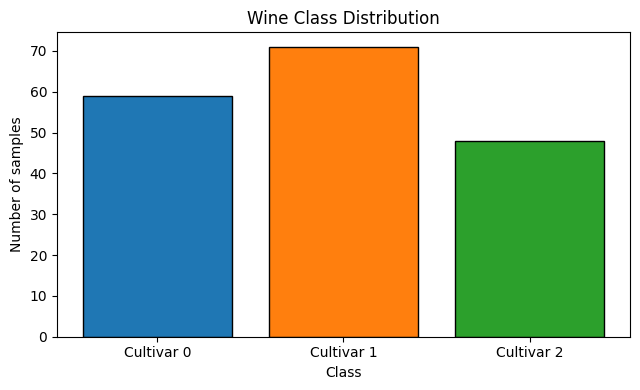

In [4]:
class_order = ["Cultivar 0", "Cultivar 1", "Cultivar 2"]
class_counts = wine_df["cultivar"].value_counts().reindex(class_order)

fig, ax = plt.subplots(figsize=(6.5, 4))

ax.bar(
    class_counts.index,
    class_counts.values,
    color=["C0", "C1", "C2"],
    edgecolor="black"
)
ax.set(
    xlabel="Class",
    ylabel="Number of samples",
    title="Wine Class Distribution"
)

fig.tight_layout()
plt.show()

## 3. A Binary Classification Problem

We begin with a yes-or-no question:

> Is this sample from Cultivar 0?

Cultivar 0 is the **positive class**, labeled 1. The other two cultivars form the
**negative class**, labeled 0. We use only alcohol and color intensity so that we can plot
the data and decision boundary in two dimensions.

In [5]:
binary_features = ["alcohol", "color_intensity"]

X = wine_df[binary_features]
y = (wine_df["target"] == 0).astype(int)

binary_preview = X.copy()
binary_preview["class"] = y.map({0: "Other", 1: "Cultivar 0"})

display(binary_preview.head())
print("Other cultivars:", (y == 0).sum())
print("Cultivar 0:", (y == 1).sum())

,alcohol,color_intensity,class
0,14.23,5.64,Cultivar 0
1,13.20,4.38,Cultivar 0
2,13.16,5.68,Cultivar 0
3,14.37,7.80,Cultivar 0
4,13.24,4.32,Cultivar 0


Other cultivars: 119
Cultivar 0: 59


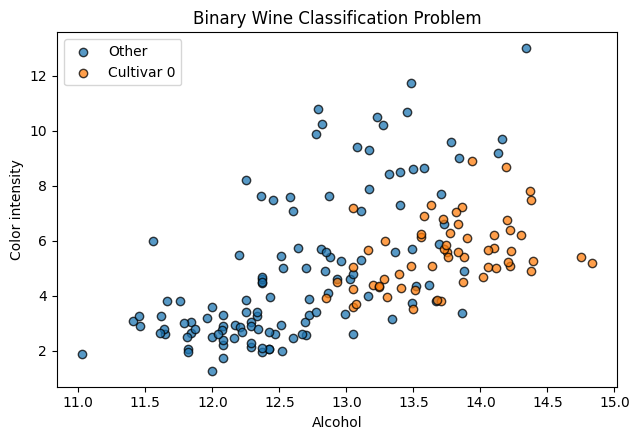

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

for label, color, name in [
    (0, "C0", "Other"),
    (1, "C1", "Cultivar 0")
]:
    selected = y == label
    ax.scatter(
        X.loc[selected, "alcohol"],
        X.loc[selected, "color_intensity"],
        color=color,
        edgecolor="black",
        alpha=0.75,
        label=name
    )

ax.set(
    xlabel="Alcohol",
    ylabel="Color intensity",
    title="Binary Wine Classification Problem"
)
ax.legend()

fig.tight_layout()
plt.show()

### Training and Test Data

We reserve 20% of the samples for the final test. `stratify=y` keeps approximately the same
class proportions in both groups.

Alcohol and color intensity have different scales. `StandardScaler` learns the training
means and standard deviations inside the pipeline, then passes the scaled features to
logistic regression.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=26,
    stratify=y
)

binary_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000))
])

binary_model.fit(X_train, y_train)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 142
Test samples: 36


## 4. From a Linear Score to a Probability

Logistic regression first computes a linear score:

$$
z = \theta_0 + \mathbf{x}^{T}\boldsymbol{\theta}.
$$

The score can take any real value, so it is not a probability. The sigmoid maps the score
to the interval from 0 to 1:

$$
\hat{p}=P(y=1\mid\mathbf{x})
=\sigma(z)
=\frac{1}{1+e^{-z}}.
$$

Equivalently, logistic regression is linear in the log-odds:

$$
\ln\left(\frac{\hat{p}}{1-\hat{p}}\right)
=\theta_0+\mathbf{x}^{T}\boldsymbol{\theta}.
$$

In [8]:
prediction_preview = X_test.copy()
prediction_preview["linear_score_z"] = binary_model.decision_function(X_test)
prediction_preview["probability_class_1"] = binary_model.predict_proba(X_test)[:, 1]
prediction_preview["predicted_class"] = binary_model.predict(X_test)
prediction_preview["actual_class"] = y_test

display(prediction_preview.head(8).round(3))

,alcohol,color_intensity,linear_score_z,probability_class_1,predicted_class,actual_class
36,13.28,4.60,-0.284,0.430,0,1
9,13.86,7.22,0.668,0.661,1,1
147,12.87,7.65,-2.649,0.066,0,0
136,12.25,3.85,-3.321,0.035,0,0
149,13.08,9.40,-2.581,0.070,0,0
142,13.52,4.35,0.571,0.639,1,0
148,13.32,8.42,-1.474,0.186,0,0
41,13.41,4.28,0.243,0.560,1,1


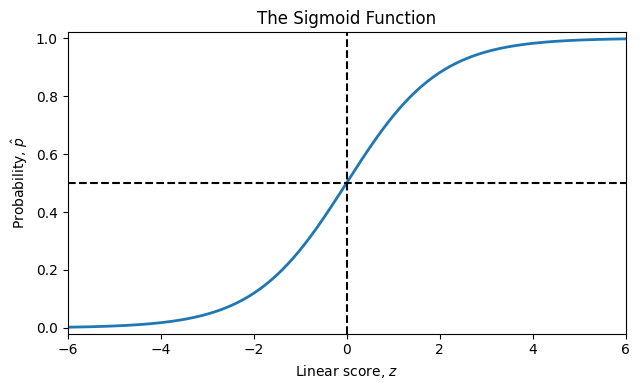

In [9]:
z = np.linspace(-6, 6, 300)
probability = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(6.5, 4))

ax.plot(z, probability, color="C0", linewidth=2)
ax.axhline(0.5, color="black", linestyle="--")
ax.axvline(0.0, color="black", linestyle="--")
ax.set(
    xlabel=r"Linear score, $z$",
    ylabel=r"Probability, $\hat{p}$",
    title="The Sigmoid Function",
    xlim=(-6, 6),
    ylim=(-0.02, 1.02)
)

fig.tight_layout()
plt.show()

### From Probability to a Class

The model produces $\hat{p}$ first. A threshold converts that probability into a class:

$$
\hat{y}=
\begin{cases}
1, & \hat{p}\geq 0.5,\\
0, & \hat{p}<0.5.
\end{cases}
$$

The threshold is a decision rule, not a parameter learned by basic logistic regression.

In [10]:
probability_examples = pd.DataFrame({
    "probability_class_1": [0.20, 0.50, 0.70]
})
probability_examples["predicted_class_at_0.5"] = (
    probability_examples["probability_class_1"] >= 0.50
).astype(int)

display(probability_examples)

,probability_class_1,predicted_class_at_0.5
0,0.2,0
1,0.5,1
2,0.7,1


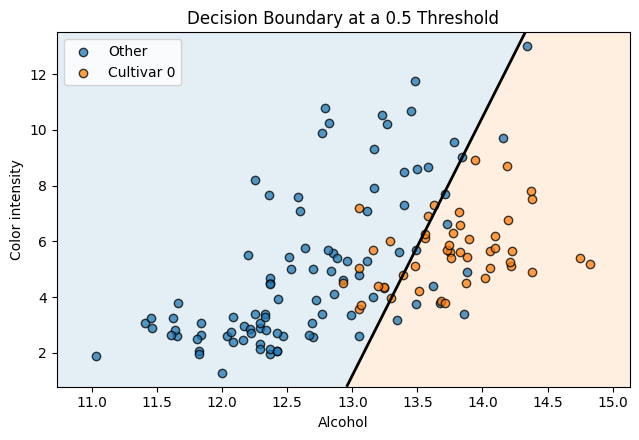

In [11]:
alcohol = np.linspace(X_train["alcohol"].min() - 0.3,
                      X_train["alcohol"].max() + 0.3, 250)
color_intensity = np.linspace(X_train["color_intensity"].min() - 0.5,
                              X_train["color_intensity"].max() + 0.5, 250)
alcohol_grid, color_grid = np.meshgrid(alcohol, color_intensity)

grid = pd.DataFrame({
    "alcohol": alcohol_grid.ravel(),
    "color_intensity": color_grid.ravel()
})
probability_grid = binary_model.predict_proba(grid)[:, 1].reshape(alcohol_grid.shape)

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.contourf(
    alcohol_grid,
    color_grid,
    probability_grid,
    levels=[0.0, 0.5, 1.0],
    colors=["C0", "C1"],
    alpha=0.12
)
ax.contour(
    alcohol_grid,
    color_grid,
    probability_grid,
    levels=[0.5],
    colors="black",
    linewidths=2
)

for label, color, name in [
    (0, "C0", "Other"),
    (1, "C1", "Cultivar 0")
]:
    selected = y_train == label
    ax.scatter(
        X_train.loc[selected, "alcohol"],
        X_train.loc[selected, "color_intensity"],
        color=color,
        edgecolor="black",
        alpha=0.75,
        label=name
    )

ax.set(
    xlabel="Alcohol",
    ylabel="Color intensity",
    title="Decision Boundary at a 0.5 Threshold"
)
ax.legend()

fig.tight_layout()
plt.show()

## 5. Binary Cross-Entropy

For one sample, binary cross-entropy is

$$
\ell_i=-y_i\ln(\hat{p}_i)-(1-y_i)\ln(1-\hat{p}_i).
$$

If $y_i=1$, the loss becomes $-\ln(\hat{p}_i)$. If $y_i=0$, it becomes
$-\ln(1-\hat{p}_i)$. A confident correct prediction has a small loss. A confident wrong
prediction has a large loss.

MSE can measure probability error, but MSE composed with a sigmoid can produce a nonconvex
training objective and small gradients for confidently wrong predictions.

In [12]:
predicted_probabilities = np.array([0.90, 0.10, 0.01])
true_class = 1

loss_comparison = pd.DataFrame({
    "Predicted probability": predicted_probabilities,
    "MSE": (predicted_probabilities - true_class) ** 2,
    "Log loss": -np.log(predicted_probabilities)
})

display(loss_comparison.round(3))

,Predicted probability,MSE,Log loss
0,0.90,0.01,0.105
1,0.10,0.81,2.303
2,0.01,0.98,4.605


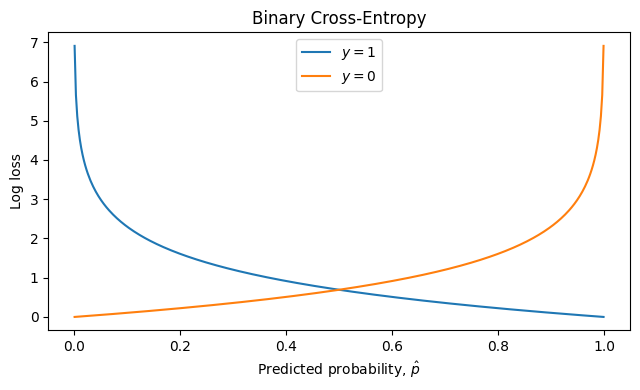

In [13]:
probability = np.linspace(0.001, 0.999, 400)
loss_when_y1 = -np.log(probability)
loss_when_y0 = -np.log(1 - probability)

fig, ax = plt.subplots(figsize=(6.5, 4))

ax.plot(probability, loss_when_y1, color="C0", label=r"$y=1$")
ax.plot(probability, loss_when_y0, color="C1", label=r"$y=0$")
ax.set(
    xlabel=r"Predicted probability, $\hat{p}$",
    ylabel="Log loss",
    title="Binary Cross-Entropy"
)
ax.legend()

fig.tight_layout()
plt.show()

### Why the Gradient Looks Familiar

Combining the sigmoid with binary cross-entropy produces a useful cancellation:

$$
\frac{\partial \ell_i}{\partial \theta_j}
=\frac{\partial \ell_i}{\partial \hat{p}_i}
 \frac{\partial \hat{p}_i}{\partial z_i}
 \frac{\partial z_i}{\partial \theta_j}
=(\hat{p}_i-y_i)x_{ij}.
$$

Therefore,

$$
\frac{\partial J}{\partial \theta_j}
=\frac{1}{n}\sum_{i=1}^{n}(\hat{p}_i-y_i)x_{ij}.
$$

This has the same residual-times-feature form as linear regression. The prediction and loss
functions are still different. Scikit-learn uses a numerical optimizer rather than the
hand-written gradient descent loop shown in the derivation.

The equations above describe the data loss. `LogisticRegression` also applies regularization
by default, connecting this model to the ideas from Lecture 9.

## 6. Evaluating the Binary Classifier

Accuracy and log loss answer different questions. Accuracy checks the final class after the
threshold. Log loss evaluates the predicted probability and penalizes confident mistakes.

Accuracy: 0.833
Log loss: 0.310


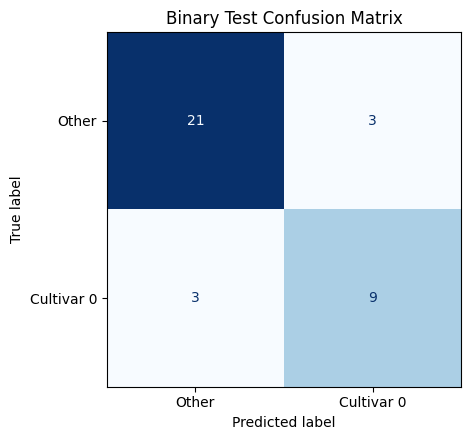

In [14]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    log_loss
)

y_pred = binary_model.predict(X_test)
y_prob = binary_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Log loss: {log_loss(y_test, y_prob):.3f}")

fig, ax = plt.subplots(figsize=(5, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Other", "Cultivar 0"],
    cmap="Blues",
    colorbar=False,
    ax=ax
)
ax.set_title("Binary Test Confusion Matrix")

fig.tight_layout()
plt.show()

### Reading the Confusion Matrix

We treat Cultivar 0 as the positive class.

| Quantity | Meaning |
| :-- | :-- |
| True positive, $TP$ | Cultivar 0 predicted as Cultivar 0 |
| False positive, $FP$ | Other cultivar predicted as Cultivar 0 |
| False negative, $FN$ | Cultivar 0 predicted as Other |
| True negative, $TN$ | Other cultivar predicted as Other |

The meaning of positive and negative comes from the question we choose, not from whether an
outcome is scientifically good or bad.

In [15]:
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:    {accuracy:.3f}")
print(f"Precision:   {precision:.3f}")
print(f"Recall:      {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 score:    {f1:.3f}")

Accuracy:    0.833
Precision:   0.750
Recall:      0.750
Specificity: 0.875
F1 score:    0.750


The five metrics summarize different parts of the confusion matrix:

$$
\mathrm{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}
$$

$$
\mathrm{Precision}=\frac{TP}{TP+FP},\qquad
\mathrm{Recall}=\frac{TP}{TP+FN}
$$

$$
\mathrm{Specificity}=\frac{TN}{TN+FP},\qquad
F_1=\frac{2TP}{2TP+FP+FN}
$$

Precision focuses on positive predictions. Recall focuses on the actual positive samples.
Specificity focuses on the actual negative samples. F1 combines precision and recall but
ignores true negatives.

### Changing the Decision Threshold

The default threshold is 0.5. A lower threshold predicts more samples as positive. A higher
threshold predicts fewer samples as positive. This changes the confusion matrix and the
resulting metrics without retraining the model.

In [16]:
threshold_results = []

for threshold in [0.30, 0.50, 0.70]:
    threshold_pred = (y_prob >= threshold).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(
        y_test,
        threshold_pred
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Predicted positives": threshold_pred.sum(),
        "Precision": precision_score(
            y_test, threshold_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, threshold_pred, zero_division=0
        ),
        "Specificity": tn_t / (tn_t + fp_t)
    })

display(pd.DataFrame(threshold_results).round(3))

,Threshold,Predicted positives,Precision,Recall,Specificity
0,0.3,13,0.769,0.833,0.875
1,0.5,12,0.750,0.750,0.875
2,0.7,5,0.800,0.333,0.958


**Discuss:** Which threshold would you choose if missing a Cultivar 0 sample were especially
costly? Which threshold would you choose if false Cultivar 0 alarms were costly?

There is no universally best classification metric or threshold. The choice depends on the
scientific decision and the relative consequences of different errors.

## 7. Multiclass Classification

The original Wine problem has three classes. One-vs-rest and one-vs-one extend binary
classifiers to this setting.

- **One-vs-rest:** train one classifier per class. Each classifier separates one class from
  all remaining classes. Choose the class with the largest decision score.
- **One-vs-one:** train one classifier for every pair of classes. Choose the class receiving
  the most votes.

With $K$ classes, one-vs-rest trains $K$ classifiers and one-vs-one trains
$K(K-1)/2$ classifiers.

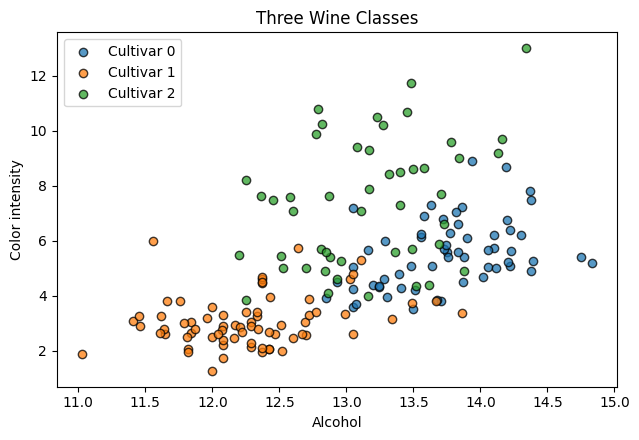

In [17]:
X_multiclass = wine_df[binary_features]
y_multiclass = wine_df["target"]

fig, ax = plt.subplots(figsize=(6.5, 4.5))

for label, color in [(0, "C0"), (1, "C1"), (2, "C2")]:
    selected = y_multiclass == label
    ax.scatter(
        X_multiclass.loc[selected, "alcohol"],
        X_multiclass.loc[selected, "color_intensity"],
        color=color,
        edgecolor="black",
        alpha=0.75,
        label=cultivar_names[label]
    )

ax.set(
    xlabel="Alcohol",
    ylabel="Color intensity",
    title="Three Wine Classes"
)
ax.legend()

fig.tight_layout()
plt.show()

In [18]:
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier


multiclass_models = {
    "One-vs-rest": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", OneVsRestClassifier(
            LogisticRegression(max_iter=2000)
        ))
    ]),
    "One-vs-one": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", OneVsOneClassifier(
            LogisticRegression(max_iter=2000)
        ))
    ])
}


X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multiclass,
    y_multiclass,
    test_size=0.20,
    random_state=26,
    stratify=y_multiclass
)

multiclass_results = []

for name, current_model in multiclass_models.items():
    current_model.fit(X_multi_train, y_multi_train)
    prediction = current_model.predict(X_multi_test)
    number_of_classifiers = len(
        current_model.named_steps["classifier"].estimators_
    )

    multiclass_results.append({
        "Strategy": name,
        "Binary classifiers": number_of_classifiers,
        "Test accuracy": accuracy_score(y_multi_test, prediction)
    })

display(pd.DataFrame(multiclass_results).round(3))

,Strategy,Binary classifiers,Test accuracy
0,One-vs-rest,3,0.889
1,One-vs-one,3,0.889


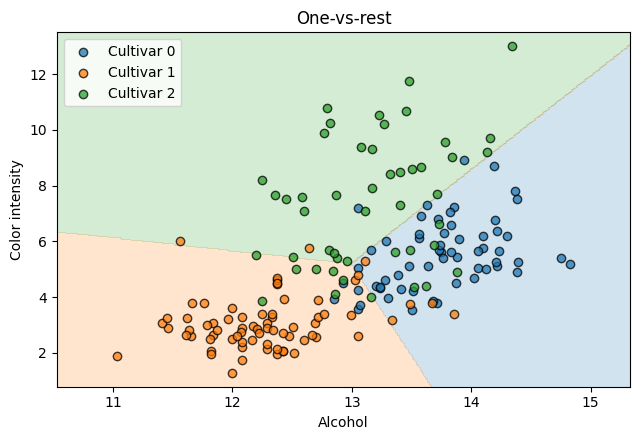

In [22]:
# Plot decision boundaries for One-vs-Rest and One-vs-One

x_min = X_multiclass["alcohol"].min() - 0.5
x_max = X_multiclass["alcohol"].max() + 0.5

y_min = X_multiclass["color_intensity"].min() - 0.5
y_max = X_multiclass["color_intensity"].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = pd.DataFrame({
    "alcohol": xx.ravel(),
    "color_intensity": yy.ravel()
})


for name, current_model in multiclass_models.items():

    predicted_class = current_model.predict(grid_points)
    zz = predicted_class.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    # Decision regions
    ax.contourf(
        xx,
        yy,
        zz,
        levels=[-0.5, 0.5, 1.5, 2.5],
        colors=["C0", "C1", "C2"],
        alpha=0.20
    )

    # Data points
    for label, color in [(0, "C0"), (1, "C1"), (2, "C2")]:
        selected = y_multiclass == label

        ax.scatter(
            X_multiclass.loc[selected, "alcohol"],
            X_multiclass.loc[selected, "color_intensity"],
            color=color,
            edgecolor="black",
            alpha=0.75,
            label=cultivar_names[label]
        )

    ax.set(
        xlabel="Alcohol",
        ylabel="Color intensity",
        title=name
    )

    ax.legend()

    fig.tight_layout()
    plt.show()

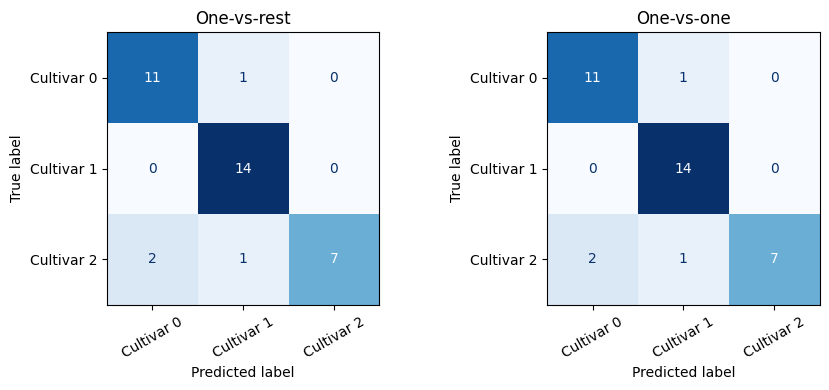

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))

for axis, (name, current_model) in zip(ax, multiclass_models.items()):
    prediction = current_model.predict(X_multi_test)

    ConfusionMatrixDisplay.from_predictions(
        y_multi_test,
        prediction,
        display_labels=["Cultivar 0", "Cultivar 1", "Cultivar 2"],
        cmap="Blues",
        colorbar=False,
        ax=axis
    )
    axis.set_title(name)
    axis.tick_params(axis="x", labelrotation=30)

fig.tight_layout()
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_multiclass, y_multiclass, test_size=0.20, random_state=26, stratify=y_multiclass
)

print(np.unique(y_multiclass))

[0 1 2]


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1))
])

svm_linear.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['alcohol','color_intensity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Accuracy: 0.8888888888888888


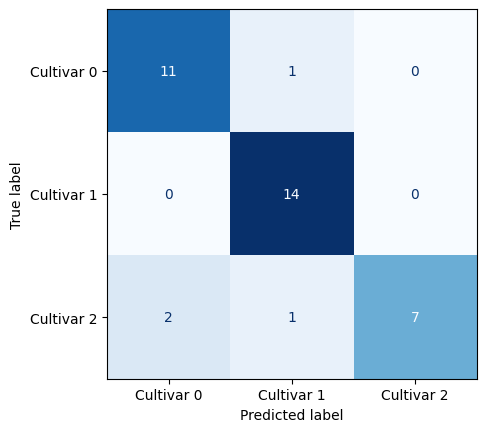

In [31]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

y_pred = svm_linear.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
        display_labels=["Cultivar 0", "Cultivar 1", "Cultivar 2"],
        cmap="Blues",
        colorbar=False)
plt.show()

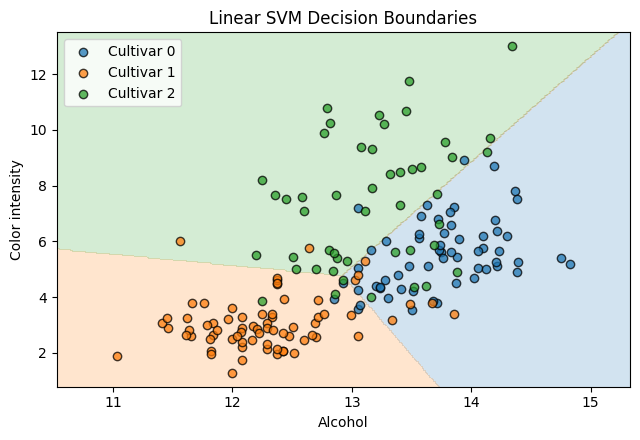

In [36]:
# Create a grid covering the feature space
x_min, x_max = X_multiclass["alcohol"].min() - 0.5, X_multiclass["alcohol"].max() + 0.5
y_min, y_max = X_multiclass["color_intensity"].min() - 0.5, X_multiclass["color_intensity"].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame({
    "alcohol": xx.ravel(),
    "color_intensity": yy.ravel()
})


# Predict the class at each location
zz = svm_linear.predict(grid).reshape(xx.shape)

# Plot decision regions
fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.contourf(
    xx, yy, zz,
    levels=[-0.5, 0.5, 1.5, 2.5],
    colors=["C0", "C1", "C2"],
    alpha=0.20
)

for label, color in [(0, "C0"), (1, "C1"), (2, "C2")]:
    selected = y_multiclass == label
    ax.scatter(
        X_multiclass.loc[selected, "alcohol"],
        X_multiclass.loc[selected, "color_intensity"],
        color=color,
        edgecolor="black",
        alpha=0.75,
        label=cultivar_names[label]
    )

ax.set(
    xlabel="Alcohol",
    ylabel="Color intensity",
    title="Linear SVM Decision Boundaries"
)

ax.legend()
fig.tight_layout()
plt.show()